# Hybrid RAG: combining the implemented RAG patterns

This notebook merges the strongest ideas already implemented in this repo into one LangGraph pipeline:

- **Hybrid retrieval**: dense FAISS + sparse BM25 fused with `EnsembleRetriever`
- **AdaptiveRAG**: route between direct answer, local retrieval, and optional web fallback
- **SelfRAG**: rewrite the query when evidence is weak and run a groundedness self-check loop
- **FlashRAG**: refine the fused context before answer generation
- **MemoRAG**: build memory summaries and use them as retrieval cues
- **RAPTOR**: add hierarchical cluster summaries for global questions
- **LightRAG / HippoRAG / GraphRAG**: add graph-style entity expansion for relationship-heavy questions

Run the notebook top-to-bottom. For best results, point it at the same PDF corpus you used in the other RAG notebooks.


In [ ]:
# Optional install (run once)
%pip install -U langchain langchain-community langchain-ollama langgraph faiss-cpu pypdf python-dotenv rank-bm25 scikit-learn networkx tavily-python


In [4]:
from __future__ import annotations

import json
import os
import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
from typing import Literal, TypedDict

import networkx as nx
import numpy as np
from dotenv import load_dotenv
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.retrievers import BM25Retriever
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from sklearn.cluster import KMeans

load_dotenv()

LOCAL_OLLAMA_BASE_URL = os.getenv("LOCAL_OLLAMA_BASE_URL", "http://localhost:11434")
LOCAL_LLM_MODEL = os.getenv("LOCAL_LLM_MODEL", "openvoid/Void-Gemini:latest")
LOCAL_EMBED_MODEL = os.getenv("LOCAL_EMBED_MODEL", "nomic-embed-text")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY", "")

TOP_K = int(os.getenv("HYBRID_RAG_TOP_K", "6"))
MEMORY_K = int(os.getenv("HYBRID_RAG_MEMORY_K", "4"))
MAX_CLUSTERS = int(os.getenv("HYBRID_RAG_MAX_CLUSTERS", "6"))
MEMORY_WINDOW_SIZE = int(os.getenv("HYBRID_RAG_MEMORY_WINDOW", "3"))
GRAPH_WINDOW_LIMIT = int(os.getenv("HYBRID_RAG_GRAPH_WINDOWS", "20"))

llm = ChatOllama(
    model=LOCAL_LLM_MODEL,
    base_url=LOCAL_OLLAMA_BASE_URL,
    temperature=0,
)
embeddings = OllamaEmbeddings(
    model=LOCAL_EMBED_MODEL,
    base_url=LOCAL_OLLAMA_BASE_URL,
)
web_search = TavilySearchResults(max_results=5) if TAVILY_API_KEY else None

print("LLM:", LOCAL_LLM_MODEL)
print("Embeddings:", LOCAL_EMBED_MODEL)
print("Web fallback enabled:", bool(web_search))


LLM: openvoid/Void-Gemini:latest
Embeddings: nomic-embed-text
Web fallback enabled: True


C:\Users\miyas\AppData\Local\Temp\ipykernel_42636\1949836226.py:47: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=5) if TAVILY_API_KEY else None


In [5]:
def candidate_pdf_paths() -> list[str]:
    rag_root = Path(r"e:\LangGraph\RAGs")
    if rag_root.exists():
        return [str(path) for path in sorted(rag_root.glob("*/*.pdf"))]
    return []


def unique_documents(documents: list[Document]) -> list[Document]:
    seen: set[tuple[str, int | None, str]] = set()
    deduped: list[Document] = []
    for doc in documents:
        key = (
            str(doc.metadata.get("source", "")),
            doc.metadata.get("page"),
            doc.page_content[:400],
        )
        if key in seen:
            continue
        seen.add(key)
        deduped.append(doc)
    return deduped


def format_documents(documents: list[Document]) -> str:
    blocks: list[str] = []
    for idx, doc in enumerate(documents, start=1):
        meta = []
        for key in ("source", "page", "chunk_id", "window_id", "cluster_id", "memory_id"):
            if key in doc.metadata:
                meta.append(f"{key}={doc.metadata[key]}")
        header = ", ".join(meta) if meta else "no-metadata"
        blocks.append(f"[Doc {idx} | {header}]\n{doc.page_content}")
    return "\n\n".join(blocks)


def strip_code_fences(text: str) -> str:
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?", "", cleaned)
        cleaned = re.sub(r"```$", "", cleaned)
    return cleaned.strip()


def extract_json_blob(text: str):
    cleaned = strip_code_fences(text)
    match = re.search(r"(\{.*\}|\[.*\])", cleaned, flags=re.DOTALL)
    if not match:
        raise ValueError("No JSON blob found.")
    return json.loads(match.group(1))


def cosine_similarity(left: list[float] | np.ndarray, right: list[float] | np.ndarray) -> float:
    left_arr = np.array(left, dtype=float)
    right_arr = np.array(right, dtype=float)
    left_norm = np.linalg.norm(left_arr)
    right_norm = np.linalg.norm(right_arr)
    if left_norm == 0 or right_norm == 0:
        return 0.0
    return float(np.dot(left_arr, right_arr) / (left_norm * right_norm))


STOPWORDS = {
    "the", "and", "for", "with", "that", "this", "from", "into", "their",
    "there", "about", "would", "could", "should", "using", "used", "have",
    "has", "had", "into", "after", "before", "where", "when", "what",
    "which", "who", "why", "how", "your", "they", "them", "were", "been",
    "will", "each", "also", "than", "such", "these", "those", "across",
    "within", "between", "through", "while", "because", "more", "most",
}


def fallback_terms(text: str, max_items: int = 6) -> list[str]:
    tokens = re.findall(r"\b[a-zA-Z][a-zA-Z0-9_-]{3,}\b", text.lower())
    counts = Counter(token for token in tokens if token not in STOPWORDS)
    return [token for token, _ in counts.most_common(max_items)]


def extract_entities(text: str, max_items: int = 6) -> list[str]:
    prompt = f'''
    Extract the most important entities, modules, concepts, or relationships from the text.
    Return only a JSON array of short strings.
    Limit: {max_items}

    TEXT:
    {text[:2500]}
    '''
    raw = llm.invoke(prompt).content
    try:
        data = extract_json_blob(raw)
        if isinstance(data, list):
            values = [str(item).strip().lower() for item in data if str(item).strip()]
            return values[:max_items]
    except Exception:
        pass
    return fallback_terms(text, max_items=max_items)


def build_memory_bank(chunks: list[Document], window_size: int = 3) -> list[Document]:
    memory_docs: list[Document] = []
    for window_id, start in enumerate(range(0, len(chunks), window_size)):
        selected = chunks[start:start + window_size]
        if not selected:
            continue
        window_text = "\n\n".join(doc.page_content for doc in selected)
        summary_prompt = f'''
        You are building compact memory for long-context retrieval.
        Summarize the passage into:
        1. key facts
        2. important entities and relationships
        3. search phrases that would help retrieve this passage later

        PASSAGE:
        {window_text[:6000]}
        '''
        summary = llm.invoke(summary_prompt).content.strip()
        memory_docs.append(
            Document(
                page_content=summary or window_text[:2000],
                metadata={
                    "source": "memory_window",
                    "window_id": window_id,
                    "chunk_indices": [doc.metadata["chunk_id"] for doc in selected],
                },
            )
        )
    return memory_docs


def build_cluster_summaries(
    chunks: list[Document],
    chunk_vectors: list[list[float]],
    max_clusters: int = 6,
) -> tuple[list[Document], dict[int, list[Document]]]:
    if not chunks:
        return [], {}

    if len(chunks) <= 4:
        summary_text = "\n\n".join(doc.page_content for doc in chunks[:4])
        summary = llm.invoke(
            f"Summarize this document section for global retrieval.\n\n{summary_text[:6000]}"
        ).content
        summary_doc = Document(
            page_content=summary,
            metadata={"source": "cluster_summary", "cluster_id": 0, "member_count": len(chunks)},
        )
        return [summary_doc], {0: chunks}

    matrix = np.array(chunk_vectors, dtype=float)
    cluster_count = min(max_clusters, max(2, len(chunks) // 4))
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=10)
    labels = model.fit_predict(matrix)

    cluster_lookup: dict[int, list[Document]] = defaultdict(list)
    for chunk, label in zip(chunks, labels):
        cluster_lookup[int(label)].append(chunk)

    summary_docs: list[Document] = []
    for cluster_id, members in sorted(cluster_lookup.items()):
        sample = "\n\n".join(doc.page_content for doc in members[:4])
        summary = llm.invoke(
            f'''
            Create a global summary for this cluster of document chunks.
            Focus on themes, entities, relationships, and anything useful for broad questions.

            CLUSTER TEXT:
            {sample[:7000]}
            '''
        ).content
        summary_docs.append(
            Document(
                page_content=summary,
                metadata={
                    "source": "cluster_summary",
                    "cluster_id": cluster_id,
                    "member_count": len(members),
                },
            )
        )
    return summary_docs, dict(cluster_lookup)


def build_entity_graph(
    memory_docs: list[Document],
    graph_window_limit: int = 20,
) -> tuple[nx.Graph, dict[str, dict], list[str], list[list[float]]]:
    graph = nx.Graph()
    memory_lookup: dict[str, dict] = {}

    for memory_doc in memory_docs[:graph_window_limit]:
        memory_id = f"memory::{memory_doc.metadata['window_id']}"
        graph.add_node(memory_id, kind="memory")
        memory_lookup[memory_id] = {
            "summary": memory_doc.page_content,
            "chunk_indices": memory_doc.metadata.get("chunk_indices", []),
        }

        entities = extract_entities(memory_doc.page_content, max_items=6)
        entity_nodes = []
        for entity in entities:
            entity_key = entity.strip().lower()
            if not entity_key:
                continue
            graph.add_node(entity_key, kind="entity")
            graph.add_edge(memory_id, entity_key)
            entity_nodes.append(entity_key)

        for left, right in combinations(sorted(set(entity_nodes)), 2):
            graph.add_edge(left, right)

    entity_names = [
        node
        for node, data in graph.nodes(data=True)
        if data.get("kind") == "entity"
    ]
    entity_vectors = embeddings.embed_documents(entity_names) if entity_names else []
    return graph, memory_lookup, entity_names, entity_vectors


available_pdfs = candidate_pdf_paths()
default_pdf_path = os.getenv(
    "HYBRID_RAG_PDF_PATH",
    available_pdfs[0] if available_pdfs else "",
)
pdf_path = input(f"Enter PDF path (default {default_pdf_path}): ").strip() or default_pdf_path
if not pdf_path:
    raise ValueError("No PDF path provided.")

loader = PyPDFLoader(pdf_path)
raw_docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(raw_docs)
for idx, chunk in enumerate(chunks):
    chunk.metadata = dict(chunk.metadata)
    chunk.metadata["source"] = chunk.metadata.get("source", pdf_path)
    chunk.metadata["chunk_id"] = idx

print(f"Loaded pages: {len(raw_docs)}")
print(f"Created chunks: {len(chunks)}")

dense_vectorstore = FAISS.from_documents(chunks, embeddings)
dense_retriever = dense_vectorstore.as_retriever(search_kwargs={"k": TOP_K})

sparse_retriever = BM25Retriever.from_documents(chunks)
sparse_retriever.k = TOP_K

hybrid_retriever = EnsembleRetriever(
    retrievers=[dense_retriever, sparse_retriever],
    weights=[0.65, 0.35],
)

chunk_vectors = embeddings.embed_documents([doc.page_content for doc in chunks])

memory_docs = build_memory_bank(chunks, window_size=MEMORY_WINDOW_SIZE)
memory_retriever = (
    FAISS.from_documents(memory_docs, embeddings).as_retriever(search_kwargs={"k": MEMORY_K})
    if memory_docs
    else None
)

cluster_summary_docs, cluster_lookup = build_cluster_summaries(
    chunks,
    chunk_vectors,
    max_clusters=MAX_CLUSTERS,
)
cluster_retriever = (
    FAISS.from_documents(cluster_summary_docs, embeddings).as_retriever(search_kwargs={"k": 3})
    if cluster_summary_docs
    else None
)

entity_graph, graph_memory_lookup, entity_names, entity_vectors = build_entity_graph(
    memory_docs,
    graph_window_limit=GRAPH_WINDOW_LIMIT,
)
entity_name_set = set(entity_names)

print("Memory windows:", len(memory_docs))
print("Hierarchy summaries:", len(cluster_summary_docs))
print("Graph nodes:", entity_graph.number_of_nodes(), "Graph edges:", entity_graph.number_of_edges())


Loaded pages: 1
Created chunks: 3
Memory windows: 1
Hierarchy summaries: 1
Graph nodes: 7 Graph edges: 21


In [6]:
class HybridRAGState(TypedDict, total=False):
    question: str
    working_query: str
    route: Literal["direct", "local", "web"]
    selected_modes: list[str]
    attempt: int
    max_attempts: int

    memory_docs: list[Document]
    memory_context: str
    retrieval_cues: str

    hybrid_docs: list[Document]
    hierarchy_docs: list[Document]
    graph_docs: list[Document]
    fused_docs: list[Document]

    refined_context: str
    web_context: str
    answer: str
    grounded: bool
    feedback: str


def heuristic_route(question: str) -> str:
    lowered = question.lower()
    if any(token in lowered for token in ("latest", "today", "current", "news", "price", "weather", "score")):
        return "web"
    if any(token in lowered for token in ("hi", "hello", "hey", "capital of", "who is")) and len(lowered.split()) <= 8:
        return "direct"
    return "local"


def route_request(state: HybridRAGState) -> HybridRAGState:
    prompt = f'''
    Choose the best route for this question.
    Return only JSON in the form {{"route": "direct" | "local" | "web"}}.

    Use:
    - "direct" for greetings or trivial common-knowledge questions
    - "local" when the answer should come from the loaded PDF
    - "web" for fresh or external information not likely in the PDF

    QUESTION:
    {state["question"]}
    '''
    raw = llm.invoke(prompt).content
    route = heuristic_route(state["question"])
    try:
        parsed = extract_json_blob(raw)
        candidate = str(parsed.get("route", route)).strip().lower()
        if candidate in {"direct", "local", "web"}:
            route = candidate
    except Exception:
        pass

    if route == "web" and web_search is None:
        route = "local"

    return {"route": route}


def direct_answer(state: HybridRAGState) -> HybridRAGState:
    answer = llm.invoke(
        f"Answer the question directly and concisely.\n\nQUESTION:\n{state['question']}"
    ).content
    return {"answer": answer, "grounded": True}


def heuristic_modes(question: str) -> list[str]:
    lowered = question.lower()
    extras: list[str] = []
    if any(token in lowered for token in ("summary", "overview", "theme", "overall", "big picture", "compare")):
        extras.append("hierarchy")
    if any(token in lowered for token in ("architecture", "module", "component", "relationship", "dependency", "flow", "pipeline")):
        extras.append("graph")
    if any(token in lowered for token in ("across", "throughout", "multiple sections", "earlier", "later", "context")):
        extras.append("memory")
    if not extras:
        extras.append("memory")
    return extras


def select_modes(state: HybridRAGState) -> HybridRAGState:
    prompt = f'''
    Dense + sparse hybrid retrieval will always run automatically.
    Choose any extra retrieval modes that would help for this question.
    Allowed values: "memory", "hierarchy", "graph"

    Return only JSON like:
    {{"extras": ["memory", "graph"]}}

    Guidance:
    - "memory": long-range clues and latent details spread across the document
    - "hierarchy": summaries, themes, comparisons, or broad/global questions
    - "graph": entities, relationships, architecture, modules, dependencies

    QUESTION:
    {state["working_query"]}
    '''
    extras = heuristic_modes(state["working_query"])
    raw = llm.invoke(prompt).content
    try:
        parsed = extract_json_blob(raw)
        candidate = [
            str(item).strip().lower()
            for item in parsed.get("extras", [])
            if str(item).strip().lower() in {"memory", "hierarchy", "graph"}
        ]
        if candidate:
            extras = list(dict.fromkeys(candidate))
    except Exception:
        pass

    selected_modes = ["hybrid"]
    for extra in extras:
        if extra not in selected_modes:
            selected_modes.append(extra)
    return {"selected_modes": selected_modes}


def build_cues(state: HybridRAGState) -> HybridRAGState:
    if memory_retriever is None:
        return {"memory_docs": [], "memory_context": "", "retrieval_cues": ""}

    memory_hits = memory_retriever.invoke(state["working_query"])
    memory_context = "\n\n".join(doc.page_content for doc in memory_hits)
    cues = ""
    if memory_context:
        cue_prompt = f'''
        Use the memory context to produce short retrieval cues that will help search the document.
        Return a concise semicolon-separated list.

        QUESTION:
        {state["working_query"]}

        MEMORY CONTEXT:
        {memory_context[:4000]}
        '''
        cues = llm.invoke(cue_prompt).content.strip()

    return {
        "memory_docs": memory_hits,
        "memory_context": memory_context,
        "retrieval_cues": cues,
    }


def retrieve_hybrid(state: HybridRAGState) -> HybridRAGState:
    hybrid_query = state["working_query"]
    if state.get("retrieval_cues"):
        hybrid_query = f"{hybrid_query}\n\nHelpful cues: {state['retrieval_cues']}"

    docs = hybrid_retriever.invoke(hybrid_query)
    return {"hybrid_docs": unique_documents(docs)}


def retrieve_hierarchy(state: HybridRAGState) -> HybridRAGState:
    if "hierarchy" not in state.get("selected_modes", []) or cluster_retriever is None:
        return {"hierarchy_docs": []}

    summary_hits = cluster_retriever.invoke(state["working_query"])
    query_vector = embeddings.embed_query(state["working_query"])
    selected_docs: list[Document] = []

    for summary_doc in summary_hits:
        selected_docs.append(summary_doc)
        cluster_id = int(summary_doc.metadata["cluster_id"])
        members = cluster_lookup.get(cluster_id, [])
        ranked_members = sorted(
            members,
            key=lambda doc: cosine_similarity(query_vector, chunk_vectors[doc.metadata["chunk_id"]]),
            reverse=True,
        )
        selected_docs.extend(ranked_members[:2])

    return {"hierarchy_docs": unique_documents(selected_docs)}


def retrieve_graph(state: HybridRAGState) -> HybridRAGState:
    if "graph" not in state.get("selected_modes", []) or not entity_names:
        return {"graph_docs": []}

    query_entities = extract_entities(state["working_query"], max_items=5)
    matched_entities: list[str] = []
    for entity in query_entities:
        if entity in entity_name_set:
            matched_entities.append(entity)
            continue
        if entity_vectors:
            query_vector = embeddings.embed_query(entity)
            scores = [cosine_similarity(query_vector, vector) for vector in entity_vectors]
            best_index = int(np.argmax(scores))
            if scores[best_index] >= 0.55:
                matched_entities.append(entity_names[best_index])

    memory_scores: Counter[str] = Counter()
    for entity in matched_entities:
        for neighbor in entity_graph.neighbors(entity):
            if entity_graph.nodes[neighbor].get("kind") == "memory":
                memory_scores[neighbor] += 2
            elif entity_graph.nodes[neighbor].get("kind") == "entity":
                for second_hop in entity_graph.neighbors(neighbor):
                    if entity_graph.nodes[second_hop].get("kind") == "memory":
                        memory_scores[second_hop] += 1

    docs: list[Document] = []
    for memory_id, _ in memory_scores.most_common(4):
        payload = graph_memory_lookup[memory_id]
        docs.append(
            Document(
                page_content=payload["summary"],
                metadata={"source": "graph_memory", "memory_id": memory_id},
            )
        )
        for chunk_index in payload.get("chunk_indices", [])[:2]:
            docs.append(chunks[chunk_index])

    return {"graph_docs": unique_documents(docs)}


def fuse_evidence(state: HybridRAGState) -> HybridRAGState:
    docs: list[Document] = []
    docs.extend(state.get("hybrid_docs", []))
    docs.extend(state.get("hierarchy_docs", []))
    docs.extend(state.get("graph_docs", []))
    if "memory" in state.get("selected_modes", []):
        docs.extend(state.get("memory_docs", []))

    fused_docs = unique_documents(docs)[:12]
    return {"fused_docs": fused_docs}


def refine_context(state: HybridRAGState) -> HybridRAGState:
    fused_docs = state.get("fused_docs", [])
    if not fused_docs:
        return {"refined_context": ""}

    packed_context = format_documents(fused_docs)
    prompt = f'''
    You are refining context before answer generation.
    Keep only the evidence that matters for the question.
    Preserve source hints when possible.

    QUESTION:
    {state["question"]}

    EVIDENCE:
    {packed_context[:12000]}
    '''
    refined = llm.invoke(prompt).content
    return {"refined_context": refined}


def answer_from_context(state: HybridRAGState, include_web: bool = False) -> str:
    sections: list[str] = []
    if state.get("refined_context"):
        sections.append(f"LOCAL CONTEXT:\n{state['refined_context']}")
    if "memory" in state.get("selected_modes", []) and state.get("memory_context"):
        sections.append(f"MEMORY CUES:\n{state['memory_context'][:3000]}")
    if include_web and state.get("web_context"):
        sections.append(f"WEB CONTEXT:\n{state['web_context']}")

    combined_context = "\n\n".join(sections).strip() or "No supporting context was retrieved."
    prompt = f'''
    Answer the question using the evidence below.
    If the evidence is weak, say what is uncertain instead of inventing details.

    QUESTION:
    {state["question"]}

    EVIDENCE:
    {combined_context}
    '''
    return llm.invoke(prompt).content


def generate_local_answer(state: HybridRAGState) -> HybridRAGState:
    return {"answer": answer_from_context(state, include_web=False)}


def self_check_answer(state: HybridRAGState) -> HybridRAGState:
    evidence = state.get("refined_context", "") or state.get("memory_context", "")
    prompt = f'''
    Judge whether the answer is grounded in the evidence.
    Return only JSON like:
    {{"grounded": true, "feedback": "short explanation"}}

    QUESTION:
    {state["question"]}

    ANSWER:
    {state["answer"]}

    EVIDENCE:
    {evidence[:8000]}
    '''
    raw = llm.invoke(prompt).content
    grounded = False
    feedback = "Could not confidently verify grounding."
    try:
        parsed = extract_json_blob(raw)
        grounded = bool(parsed.get("grounded", False))
        feedback = str(parsed.get("feedback", feedback)).strip() or feedback
    except Exception:
        lowered = raw.lower()
        grounded = "true" in lowered and "false" not in lowered
        feedback = raw.strip() or feedback

    return {"grounded": grounded, "feedback": feedback}


def rewrite_query(state: HybridRAGState) -> HybridRAGState:
    prompt = f'''
    Rewrite the retrieval query to improve the next search attempt.
    Keep it specific and grounded in the user's question.
    Return only the rewritten query.

    ORIGINAL QUESTION:
    {state["question"]}

    CURRENT QUERY:
    {state["working_query"]}

    FEEDBACK:
    {state.get("feedback", "")}

    MEMORY CUES:
    {state.get("retrieval_cues", "")}
    '''
    rewritten = llm.invoke(prompt).content.strip()
    rewritten = strip_code_fences(rewritten).splitlines()[0].strip() if rewritten else state["question"]
    return {
        "working_query": rewritten or state["question"],
        "attempt": state.get("attempt", 0) + 1,
    }


def web_retrieve(state: HybridRAGState) -> HybridRAGState:
    if web_search is None:
        return {"web_context": ""}

    try:
        results = web_search.invoke({"query": state["working_query"]})
    except Exception:
        results = web_search.invoke(state["working_query"])

    if isinstance(results, str):
        context = results
    else:
        items = results if isinstance(results, list) else [results]
        formatted: list[str] = []
        for item in items[:5]:
            if isinstance(item, dict):
                title = item.get("title") or item.get("url") or "Web result"
                content = item.get("content") or item.get("snippet") or ""
                url = item.get("url", "")
                formatted.append(f"{title}\n{content}\n{url}".strip())
            else:
                formatted.append(str(item))
        context = "\n\n".join(formatted)

    return {"web_context": context, "route": "web"}


def generate_web_answer(state: HybridRAGState) -> HybridRAGState:
    return {"answer": answer_from_context(state, include_web=True), "grounded": True}


def route_after_request(state: HybridRAGState) -> Literal["direct", "local", "web"]:
    return state["route"]


def route_after_check(state: HybridRAGState) -> Literal["rewrite_query", "web_retrieve", "__end__"]:
    if state.get("grounded"):
        return "__end__"
    if state.get("attempt", 0) + 1 < state.get("max_attempts", 2):
        return "rewrite_query"
    if web_search is not None:
        return "web_retrieve"
    return "__end__"


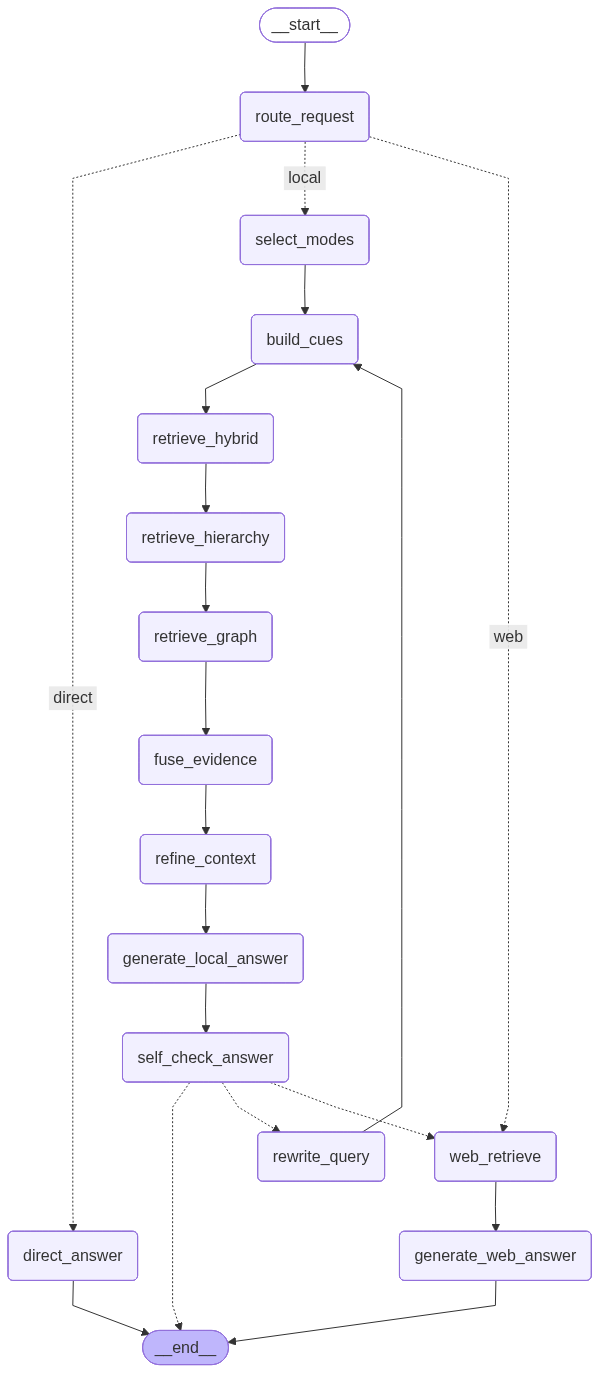

In [7]:
builder = StateGraph(HybridRAGState)

builder.add_node("route_request", route_request)
builder.add_node("direct_answer", direct_answer)
builder.add_node("select_modes", select_modes)
builder.add_node("build_cues", build_cues)
builder.add_node("retrieve_hybrid", retrieve_hybrid)
builder.add_node("retrieve_hierarchy", retrieve_hierarchy)
builder.add_node("retrieve_graph", retrieve_graph)
builder.add_node("fuse_evidence", fuse_evidence)
builder.add_node("refine_context", refine_context)
builder.add_node("generate_local_answer", generate_local_answer)
builder.add_node("self_check_answer", self_check_answer)
builder.add_node("rewrite_query", rewrite_query)
builder.add_node("web_retrieve", web_retrieve)
builder.add_node("generate_web_answer", generate_web_answer)

builder.add_edge(START, "route_request")
builder.add_conditional_edges(
    "route_request",
    route_after_request,
    {
        "direct": "direct_answer",
        "local": "select_modes",
        "web": "web_retrieve",
    },
)

builder.add_edge("direct_answer", END)

builder.add_edge("select_modes", "build_cues")
builder.add_edge("build_cues", "retrieve_hybrid")
builder.add_edge("retrieve_hybrid", "retrieve_hierarchy")
builder.add_edge("retrieve_hierarchy", "retrieve_graph")
builder.add_edge("retrieve_graph", "fuse_evidence")
builder.add_edge("fuse_evidence", "refine_context")
builder.add_edge("refine_context", "generate_local_answer")
builder.add_edge("generate_local_answer", "self_check_answer")

builder.add_conditional_edges(
    "self_check_answer",
    route_after_check,
    {
        "rewrite_query": "rewrite_query",
        "web_retrieve": "web_retrieve",
        "__end__": END,
    },
)

builder.add_edge("rewrite_query", "build_cues")
builder.add_edge("web_retrieve", "generate_web_answer")
builder.add_edge("generate_web_answer", END)

app = builder.compile()
app


In [ ]:
def run_hybrid_rag(question: str, max_attempts: int = 2) -> HybridRAGState:
    initial_state: HybridRAGState = {
        "question": question,
        "working_query": question,
        "attempt": 0,
        "max_attempts": max_attempts,
        "selected_modes": [],
        "memory_docs": [],
        "hybrid_docs": [],
        "hierarchy_docs": [],
        "graph_docs": [],
        "fused_docs": [],
    }
    return app.invoke(initial_state)


example_question = "What are the main architectural components or modules described in this document?"
example_result = run_hybrid_rag(example_question)

print("Question:", example_question)
print("Route:", example_result.get("route"))
print("Modes:", example_result.get("selected_modes"))
print("Grounded:", example_result.get("grounded"))
print("Attempts:", example_result.get("attempt"))
print("\nAnswer:\n", example_result.get("answer"))


while True:
    user_query = input("\nAsk your question (or type 'exit'): ").strip()
    if user_query.lower() in {"exit", "quit", "q"}:
        print("Stopped.")
        break
    if not user_query:
        print("Please enter a valid question.")
        continue

    result = run_hybrid_rag(user_query)
    print("\n=== Route ===")
    print(result.get("route"))
    print("\n=== Modes ===")
    print(result.get("selected_modes"))
    print("\n=== Grounded ===")
    print(result.get("grounded"))
    print("\n=== Answer ===")
    print(result.get("answer"))


Question: What are the main architectural components or modules described in this document?
Route: local
Modes: ['hybrid', 'hierarchy', 'graph']
Grounded: True
Attempts: 0

Answer:
 Based on the provided evidence, the document describes architectural components and modules for three distinct projects:

**1. University Management System**
*   **Functional Modules:** Student enrollment, faculty profiles, fee records, results management, and enrollment tracking.
*   **System Components:** Role-based access control, automated email notifications, and a database (MySQL).
*   **Framework:** Flask.

**2. AI-Powered ASL Translator**
*   **Functional Modules:** Real-time video translation, static image translation, custom model training, and performance visualization.
*   **Core Technologies:** OpenCV and MediaPipe.

**3. Real-Time Chat Application**
*   **Functional Modules:** Login/signup, OTP-based password recovery, public and private chatrooms, and an admin panel.
*   **Communication Compo